## Гауссово распределение, линейный дискриминантный анализ и наивный байес

### 1. Многомерное гауссово распределение
Создайте случайную выборку данных с двумерным гауссовым распределением. Для этого сперва сделайте два вектора из двух одномерных распределений с разными стандартными отклонениями $\sigma_1$ и $\sigma_2$, как показано ниже:  
``` python
import numpy as np

M = 200
sigma1 = 0.1
sigma2 = 0.5
x1 = np.random.randn(M, 1) * sigma1
x2 = np.random.randn(M, 1) * sigma2
X = np.concatenate((x1, x2), axis=1)
```
После чего сделайте матрицу поворота на угол $\alpha$ и с помощью неё поверните набор точек в пространстве.  
Посчитайте матрицу ковариации для сгенерированных точек.  
Нарисуйте полученное облако точек и сравните его с облаком точек, полученных с помощью готовой функции:  `np.random.multivariate_normal()`


Mean of Samples:
[ 0.02070812 -0.05375808]
Covariance of Samples:
[[ 0.10249493 -0.02417706]
 [-0.02417706  0.56495557]]


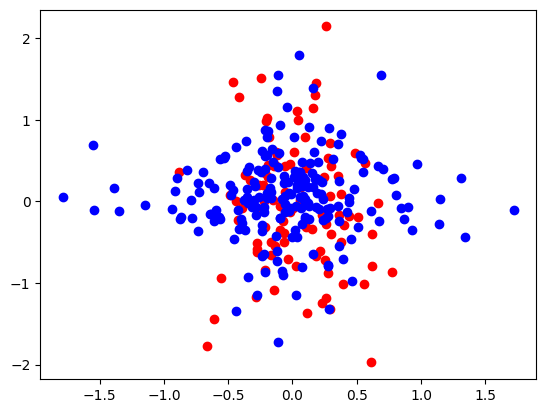

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

def M(fi):
    A = np.zeros((2,2))
    A[0, 0] = np.cos(fi)
    A[0, 1] = np.sin(fi)
    A[1, 0] = -np.sin(fi)
    A[1, 1] = np.cos(fi)
    A = np.array(A)
    return A

Ma = 100
sigma1 = 0.1
sigma2 = 0.5
x1 = np.random.randn(Ma, 1) * sigma1**(1/2)
x2 = np.random.randn(Ma, 1) * sigma2**(1/2)
X = np.concatenate((x1, x2), axis=1)
X = np.array(X)

Y = X.dot(M(np.pi/2))

# Определение среднего значения
mean = np.array([0, 0])


cov = np.array([[sigma1, 0], [0, sigma2]])

# Генерация 1000 случайных образцов из многомерного нормального распределения
samples = np.random.multivariate_normal(mean, cov, Ma)

plt.scatter(samples[:, 0], samples[:, 1], c = 'r')
plt.scatter(X[:, 0], X[:, 1], c = 'b')
plt.scatter(Y[:, 0], Y[:, 1], c = 'b')

# Печать среднего значения и covariance сгенерированных образцов
print("Mean of Samples:")
print(np.mean(samples, axis=0))
print("Covariance of Samples:")
print(np.cov(samples, rowvar=False))

### 2. Плотность вероятности гауссового распределения
В общем виде $n$-мерное гауссово распределение имеет вид:  
$$p(x) = \frac{1}{(\sqrt{2\pi})^n \sqrt{detC}} e^{-\frac{1}{2}(x-\mu)^TС^{-1}(x-\mu)} \tag{1}$$  
где $x\in{R^n}$, $\mu\in{R^n}$ - среднее значение, $C$ - матрица ковариации.  

Сгенерируйте набор точек в двумерном пространстве (как делали в пункте 1 или другим способом). Посчитайте для них среднее значение и матрицу ковариации $\mu$ и $C$. Для оценки плотности вероятности (probability density function - `pdf`) гауссового распределения в произвольной точке используйте `scipy.stats.multivariate_normal`
(https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html), либо можете посчитать вручную.  

Визуализируйте набор точек и плотность вероятности, для чего изобразите точки одним цветом, а фон раскрасьте в соответсвии с плотностью вероятности, для чего можете использовать пример ниже:  

``` python
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import multivariate_normal

xx = np.linspace(-1, 1, 100)
yy = np.linspace(-1, 1, 100)
XX, YY = np.meshgrid(xx, yy)
pp = np.stack((XX.flatten(), YY.flatten()), axis=1)
m = multivariate_normal(mean=[0,0], cov=[[0.3, 0], [0, 0.1]])
ZZ = m.pdf(pp).reshape(XX.shape)

IMG = plt.pcolor(XX, YY, ZZ)
plt.colorbar(IMG)

CS = plt.contour(XX, YY, m.pdf(pp).reshape(XX.shape), levels=[0.2, 0.4, 0.6, 0.8, 0.9], colors='k')
plt.clabel(CS, inline=1, fontsize=10)
```

матрица ковариации:
[[0.20169997 0.00887142]
 [0.00887142 0.52514839]] 

среднее значение
[-0.00528581 -0.02875448]


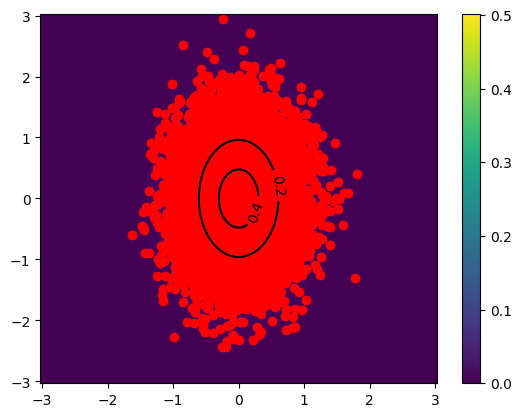

In [11]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(1)

Ma = 10000
sigma1 = 0.2
sigma2 = 0.5
x1 = np.random.randn(Ma, 1) * sigma1**(1/2)
x2 = np.random.randn(Ma, 1) * sigma2**(1/2)
X = np.concatenate((x1, x2), axis=1)
X = np.array(X)

xx = np.linspace(-sigma1*15, sigma1*15, 100)
yy = np.linspace(-sigma2*6, sigma2*6, 100)
XX, YY = np.meshgrid(xx, yy)
pp = np.stack((XX.flatten(), YY.flatten()), axis=1)
m = multivariate_normal(mean=[0,0], cov=[[sigma1, 0], [0, sigma2]])

ZZ = m.pdf(pp).reshape(XX.shape)

IMG = plt.pcolor(XX, YY, ZZ)
plt.colorbar(IMG)

CS = plt.contour(XX, YY, m.pdf(pp).reshape(XX.shape), levels=[0.2, 0.4, 0.6, 0.8, 0.9], colors='k')
plt.clabel(CS, inline=1, fontsize=10)
plt.scatter(X[:, 0], X[:, 1], c='r')


points = m.rvs(size = 1000)
cov_matrix = np.cov(points, rowvar=False)
mean = np.mean(points, axis=0)

print("матрица ковариации:")
print(cov_matrix, '\n')
print('среднее значение')
print(mean)

#### Видим гистограмму похожую на распеделение Пуассона, значит имеем что-то похожее на Гауссовское разпределение в массиве 'X'

### 3. Бинарная классификация

**Задание**
Создайте случайный датасет, состоящий из двух классов $y\in{\{0, 1\}}$, а признаки имеют две координаты. Посчитайте для каждого класса среднее значение и матрицу ковариации $\mu_0, \mu_1$ и $C_0, C_1$.

Решение задачи классификации можно свести к оценке максимальной апостериорной вероятности (Maximum a posterior - MAP):
$$y = \underset{y\in{0,1}}{argmax} p(y|x) \tag{2}$$  
которая в свою очередь через теорему Байеса равна:  
$$p(y|x) = \frac{p(x|y)p(y)}{p(x)} \tag{3}$$
В последней формуле вероятность p(y) называется априорной и не зависит от $x$ - оценить её можно просто как долю точек датасета принадлежащего заданному классу $y$. Вероятность p(x|y) называют правдоподобием (likelyhood). Обычно правдоподобие моделируется некоторой генерирующей моделью, например по формуле гаусса (1), и говорит насколько правдоподобно что точка с координатами $x$ могла быть "сгенерирована" в классе $y$. Знаменатель $p(x)$ в последней формуле не зависит от $y$, поэтому на него внимание не обращаем.  

Таким образом, для бинарной классификации, т.е. для оценки принадлежности некоторой точки $x$ к классу 0 или 1, нужно сравнить две величины:  
$$p(x|y=0)p(y=0) \overset{?}{<>} p(x|y=1)p(y=1) \tag{4}$$

**Задание**
Визуализируейте на одном рисунке датасет с точками обоих классов разными цветами. Раскрасьте фон изображения в соответствии с разностью левой и правой частей уравнения (4). Постройте на этом же рисунке разделяющую кривую, т.е. кривую соответствующую нулевой разнице между левой и правой частями. Для её построения используйте функции `plt.contour` с указанием конкретного уровня.

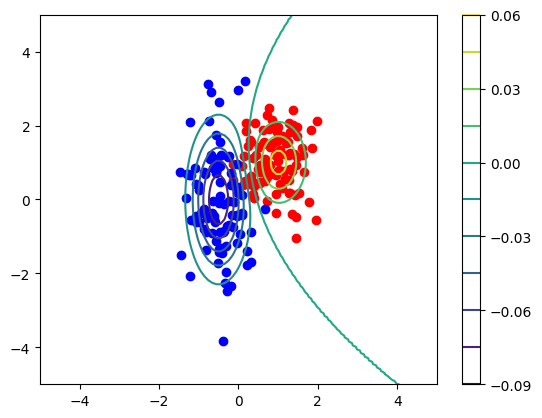

In [ ]:
import pandas as pd
mean1 = [1,1]
mean2 = [-.5,0]
cov1 = [[sigma1, 0], [0, sigma2]]
cov2 = [[sigma1, 0], [0, 3*sigma2]]
m1 = multivariate_normal(mean=mean1, cov=cov1)
m2 = multivariate_normal(mean=mean2, cov=cov2)
x1 = m1.rvs(size = 100)
x2 = m2.rvs(size = 100)

plt.scatter(x1[:, 0], x1[:, 1], c = 'r')
plt.scatter(x2[:, 0], x2[:, 1], c = 'b')
X = np.concatenate((x1, x2), axis=0)
Y = np.concatenate((np.zeros(100), np.ones(100)))
#p(y =1) = 0.5 
#p(y =0) = 0.5

def gaussian_likelihood(x, mu, sigma):
    d = len(mu)
    det_sigma = np.linalg.det(sigma)
    inv_sigma = np.linalg.inv(sigma)
    diff = x - mu
    exponent = -0.5 * np.dot(diff.T, np.dot(inv_sigma, diff))
    likelihood = (1 / (2 * np.pi)**(d/2) * det_sigma**(1/2)) * np.exp(exponent)
    return likelihood

def f(x, y):
    vect = np.array([x,y])
    return gaussian_likelihood(vect, mean1, cov1) - gaussian_likelihood(vect, mean2, cov2)


x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)


Z = np.vectorize(f)(X, Y)


plt.contour(X, Y, Z, levels=10, cmap='viridis')
plt.colorbar()
plt.show()



### 4. LDA (linear discriminant analysis)

**Задание** Рассмотрите частный случай, когда для точек двух классов матрицы ковариации совпадают, т.е. $C_0=C_1$, но средние значения отличаются $\mu_0\neq\mu_1$. Выпишите явное выражение для разделяющей поверхности в этом случае. Визуализируйте такой случай аналогично предыдущему пункту. Про линейный и квадратичный дискриминантный анализ можете почитать здесь (https://scikit-learn.org/stable/modules/lda_qda.html) или в учебнике Яндекса по ML (https://education.yandex.ru/handbook/ml/article/generativnyj-podhod-k-klassifikacii)

Реализуйте классификатор на основе метода линейного дискриминантного анализа по шаблону ниже. Данный алгоритм предполагает одинаковость матриц ковариации (т.е. считает одну общую матрицу ковариации, но разные средние) и использует линейное правило классификации. Желательно сделать реализацию, которая подходит не только для двумерного, но и для более общего случая.

```python
from sklearn.base import BaseEstimator

class myLDA(BaseEstimator):
    def __init__(self):
        pass
    
    def fit(self, X, y):
        pass
    
    def predict(self, X):
        pass
```


### 5. Наивный байесовый классификатор (NaiveBayes)

**Задание**
Прочитать по наивный байесовый подход можно здесь (https://scikit-learn.org/stable/modules/naive_bayes.html) или в учебнике Яндекса по ML (https://education.yandex.ru/handbook/ml/article/generativnyj-podhod-k-klassifikacii).  

Суть наивного предположения состоит в том, чтобы не считать совместную плотность вероятности для $n$-мерного случая, а рассматривать каждую переменную как независимую и считать одномерные распределения:  
$$p(x_1,x_2,...,x_n|y) => \prod\limits_{i=1}^{n}p(x_i|y)$$  
Это можно также рассматривать как обнуление всех внедиагональных элементов матрицы ковариации.  

**Задание**
Реализуйте классификатор на основе наивного байесового подхода с одномерным гауссовым распределением для каждой переменной. Желательно сделать реализацию, которая подходит не только для двумерного, но и для более общего случая.

```python
from sklearn.base import BaseEstimator

class myNB(BaseEstimator):
    def __init__(self):
        pass
    
    def fit(self, X, y):
        pass
    
    def predict(self, X):
        pass
```

In [33]:
from sklearn.base import BaseEstimator
from sklearn.utils.validation import check_X_y, check_array

class NaiveBayesEstimator(BaseEstimator):
    def __init__(self):
        pass

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = np.unique(y)
        self.means_ = []
        self.variances_ = []
        self.priors_ = []

        for c in self.classes_:
            X_c = X[y == c]
            mean = np.mean(X_c, axis=0)
            variance = np.var(X_c, axis=0)
            prior = np.mean(y == c)
            self.means_.append(mean)
            self.variances_.append(variance)
            self.priors_.append(prior)

        return self

    def predict(self, X):
        X = check_array(X)
        posterior_probabilities = self._predict_proba(X)
        return np.argmax(posterior_probabilities, axis=1)

    def _predict_proba(self, X):
        posterior_probabilities = []
        for i, c in enumerate(self.classes_):
            mean = self.means_[i]
            variance = self.variances_[i]
            prior = self.priors_[i]
            likelihood = np.exp(-((X - mean) ** 2) / (2 * variance)) / np.sqrt(2 * np.pi * variance)
            posterior_probability = np.prod(likelihood, axis=1) * prior
            posterior_probabilities.append(posterior_probability)

        posterior_probabilities = np.stack(posterior_probabilities, axis=1)
        return posterior_probabilities

### 6. Сравнение двух алгоритмов: LDA и NB

Создайте датасет для бинарной классификации, либо вручную либо используйте функцию `sklearn.datasets.make_classification`
(https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html)  

Разделите датасет на обучающую и тестовую подвыборки.  
Проверьте работоспособность разработанных вами двух алгоритмов.  
Посчитайте основные метрики классификации: долю правильных ответов (accuracy), точность (Precision) и полноту (Recall).  
(про метрики прочитайте здесь https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii)  
Сделайте выводы.  

In [ ]:

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score


# Generate a dataset for binary classification
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=5, n_repeated=0, n_classes=2, random_state=42)

# Split the dataset into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = NaiveBayesEstimator().fit(X_train, y_train)

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)




Accuracy: 0.795
Precision: 0.8
Recall: 0.7755102040816326
